In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel('./Data/online_retail_II.xlsx')

# Data Understanding

In [5]:
# 1. Shape
print("Shape:", df.shape)

# 2. First 5 rows
display(df.head())

# 3. Dataset information
df.info()

# 4. Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# 5. Missing values
print("\nMissing values:")
print(df.isnull().sum())

# 6. Descriptive statistics
display(df.describe())

Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB

Duplicate rows: 6865

Missing values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


# Data Quality Investigation

In [6]:
# Negative Quantity
print('Negative Quantities:', (df['Quantity'] < 0).sum())

# Zero Quantity
print('Zero Quantities:', (df['Quantity'] == 0).sum())

# Negative Prices
print('Negative Prices:', (df['Price'] < 0).sum())

# Zero Prices
print('Zero Prices:', (df['Price'] == 0).sum())

# Cancelled Invoices
print('Cancelled Inovice:', (df['Invoice'].astype(str).str.startswith('C')).sum())

# Missing Customer IDs
print('Missing Customer Ids:', (df['Customer ID'].isna().sum()))

Negative Quantities: 12326
Zero Quantities: 0
Negative Prices: 3
Zero Prices: 3687
Cancelled Inovice: 10206
Missing Customer Ids: 107927


In [7]:
display(df[df['Quantity'] < 0].head(10))

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [8]:
display(df[df['Price'] < 0].head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [9]:
# Zero-price transactions
print("Zero-price transactions:", (df["Price"] == 0).sum())

display(
    df[df["Price"] == 0].head(20)
)

Zero-price transactions: 3687


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [10]:
# Missing Customer ID Transactions
Missing_Customer = df[df['Customer ID'].isna()]

print('Rows with missing Customer ID:', len(Missing_Customer))

display(Missing_Customer.head(10))

Rows with missing Customer ID: 107927


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [11]:
# Missing Customer ID by invoice
print(
    Missing_Customer["Invoice"]
    .astype(str)
    .str.startswith("C")
    .value_counts()
)

Invoice
False    107560
True        367
Name: count, dtype: int64


# Data Cleaning

In [12]:
# Create Copy
df_clean = df.copy()

# Remove Duplicate Rows
df_clean = df_clean.drop_duplicates()

# Remove missing Customer IDs
df_clean = df_clean.dropna(subset=['Customer ID'])

# Remove zero and negative prices
df_clean = df_clean[df_clean['Price'] > 0]

# Create Revenue
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

# Convert Customer ID to integer
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)

# Check result
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (525461, 8)
Cleaned shape: (410732, 9)


In [13]:
print("Duplicates:", df_clean.duplicated().sum())
print("Missing Customer ID:", df_clean["Customer ID"].isna().sum())
print("Zero/negative prices:", (df_clean["Price"] <= 0).sum())

display(df_clean.head())

Duplicates: 0
Missing Customer ID: 0
Zero/negative prices: 0


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


# Understand Customer Transactions

In [14]:
# Number of unique customers
print("Unique Customers:", df_clean["Customer ID"].nunique())
print('='*70)

# Number of unique invoices
print("Unique Invoices:", df_clean["Invoice"].nunique())
print('='*70)

# Returns vs purchases
print('Returns Rows:', (df_clean['Quantity'] < 0).sum())  # Return Products
print('Purchase Rows:', (df_clean['Quantity'] > 0).sum()) # Purchased Products
print('='*70)

# Revenue overview
print("Total Revenue:", df_clean["Revenue"].sum())
print("Average Transaction Revenue:", df_clean["Revenue"].mean())
print("Minimum Revenue:", df_clean["Revenue"].min())
print("Maximum Revenue:", df_clean["Revenue"].max())
print('='*70)

# Remaining Cancelled Invoice
print(
    "Cancelled invoices:",
    df_clean["Invoice"].astype(str).str.startswith("C").sum()
)

Unique Customers: 4381
Unique Invoices: 23585
Returns Rows: 9816
Purchase Rows: 400916
Total Revenue: 8314855.584000001
Average Transaction Revenue: 20.24399263753494
Minimum Revenue: -25111.09
Maximum Revenue: 15818.4
Cancelled invoices: 9816


In [15]:
# Separate purchases and returns Copy

# Purchases
purchases = df_clean[df_clean['Quantity'] > 0].copy()

# Returns
returns = df_clean[df_clean['Quantity'] < 0].copy()

print("Purchase rows:", len(purchases))
print("Return rows:", len(returns))

Purchase rows: 400916
Return rows: 9816


In [16]:
# Custom Metrics

customer_df = purchases.groupby("Customer ID").agg(
    Total_Orders=("Invoice", "nunique"),
    Total_Items=("Quantity", "sum"),
    Total_Revenue=("Revenue", "sum"),
    First_Purchase=("InvoiceDate", "min"),
    Last_Purchase=("InvoiceDate", "max")
).reset_index()

In [17]:
customer_df['Average_Order_Value'] = (
    customer_df['Total_Revenue'] /
    customer_df['Total_Orders']
)

In [18]:
return_df = returns.groupby('Customer ID').agg(
    Return_Transactions = ('Invoice', 'nunique'),
    Returned_Items = ('Quantity', 'sum'),
    Return_Value = ('Revenue', 'sum')
).reset_index()

return_df["Returned_Items"] = return_df["Returned_Items"].abs()
return_df["Return_Value"] = return_df["Return_Value"].abs()

In [19]:
# Merge the Customer df with return
customer_df = customer_df.merge(
    return_df,
    on='Customer ID',
    how='left'
)

# Customer Without returns
customer_df[[
    "Return_Transactions",
    "Returned_Items",
    "Return_Value"
]] = customer_df[[
    "Return_Transactions",
    "Returned_Items",
    "Return_Value"
]].fillna(0)

In [20]:
print("Customer dataset shape:", customer_df.shape)

display(customer_df.head())

customer_df.info()

Customer dataset shape: (4312, 10)


,Customer ID,Total_Orders,Total_Items,Total_Revenue,First_Purchase,Last_Purchase,Average_Order_Value,Return_Transactions,Returned_Items,Return_Value
0,12346,11,70,372.86,2009-12-14 08:34:00,2010-06-28 13:53:00,33.896364,4.0,17.0,424.60
1,12347,2,828,1323.32,2010-10-31 14:20:00,2010-12-07 14:57:00,661.660000,0.0,0.0,0.00
2,12348,1,373,222.16,2010-09-27 14:59:00,2010-09-27 14:59:00,222.160000,0.0,0.0,0.00
3,12349,3,993,2671.14,2010-04-29 13:20:00,2010-10-28 08:23:00,890.380000,1.0,5.0,24.15
4,12351,1,261,300.93,2010-11-29 15:23:00,2010-11-29 15:23:00,300.930000,0.0,0.0,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer ID          4312 non-null   int64         
 1   Total_Orders         4312 non-null   int64         
 2   Total_Items          4312 non-null   int64         
 3   Total_Revenue        4312 non-null   float64       
 4   First_Purchase       4312 non-null   datetime64[ns]
 5   Last_Purchase        4312 non-null   datetime64[ns]
 6   Average_Order_Value  4312 non-null   float64       
 7   Return_Transactions  4312 non-null   float64       
 8   Returned_Items       4312 non-null   float64       
 9   Return_Value         4312 non-null   float64       
dtypes: datetime64[ns](2), float64(5), int64(3)
memory usage: 337.0 KB


In [21]:
# Customer lifespan in days
customer_df['Customer_Lifespan_Days'] = (
    customer_df['Last_Purchase'] - 
    customer_df['First_Purchase']
).dt.days

# Purchase frequency
customer_df['Purchase_Frequency'] = (
    customer_df['Total_Orders'] / 
    (customer_df['Customer_Lifespan_Days'] / 30 + 1)
)

display(customer_df.head())

,Customer ID,Total_Orders,Total_Items,Total_Revenue,First_Purchase,Last_Purchase,Average_Order_Value,Return_Transactions,Returned_Items,Return_Value,Customer_Lifespan_Days,Purchase_Frequency
0,12346,11,70,372.86,2009-12-14 08:34:00,2010-06-28 13:53:00,33.896364,4.0,17.0,424.60,196,1.460177
1,12347,2,828,1323.32,2010-10-31 14:20:00,2010-12-07 14:57:00,661.660000,0.0,0.0,0.00,37,0.895522
2,12348,1,373,222.16,2010-09-27 14:59:00,2010-09-27 14:59:00,222.160000,0.0,0.0,0.00,0,1.000000
3,12349,3,993,2671.14,2010-04-29 13:20:00,2010-10-28 08:23:00,890.380000,1.0,5.0,24.15,181,0.426540
4,12351,1,261,300.93,2010-11-29 15:23:00,2010-11-29 15:23:00,300.930000,0.0,0.0,0.00,0,1.000000


In [22]:
customer_df[
    [
        "Total_Orders",
        "Total_Items",
        "Total_Revenue",
        "Average_Order_Value",
        "Return_Transactions",
        "Returned_Items",
        "Return_Value",
        "Customer_Lifespan_Days",
        "Purchase_Frequency"
    ]
].describe()

,Total_Orders,Total_Items,Total_Revenue,Average_Order_Value,Return_Transactions,Returned_Items,Return_Value,Customer_Lifespan_Days,Purchase_Frequency
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,4.455705,1280.050557,2040.406712,376.373364,0.996521,48.916744,97.580401,133.998609,0.912209
std,8.170213,6457.926351,8911.755977,492.357455,2.458043,1366.487550,862.103985,132.827183,0.684186
min,1.000000,1.000000,2.950000,2.950000,0.000000,0.000000,0.000000,0.000000,0.153453
25%,1.000000,156.000000,307.187500,179.490000,0.000000,0.000000,0.000000,0.000000,0.526316
50%,2.000000,380.000000,701.615000,285.048333,0.000000,0.000000,0.000000,105.000000,1.000000
75%,5.000000,992.000000,1714.932500,421.483750,1.000000,5.000000,23.275000,254.000000,1.000000
max,205.000000,220600.000000,349164.350000,11880.840000,65.000000,87563.000000,26477.400000,373.000000,15.260546


# RFM Analysis
RFM =<br>
Recency → How recently did the customer purchase?<br>
Frequency → How often did they purchase?<br>
Monetary → How much did they spend?

In [23]:
analysis_date = df_clean["InvoiceDate"].max()

print("Analysis Date:", analysis_date)

Analysis Date: 2010-12-09 20:01:00


In [24]:
# Calculate RFM
rfm = purchases.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (analysis_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary
0,12346,164,11,372.86
1,12347,2,2,1323.32
2,12348,73,1,222.16
3,12349,42,3,2671.14
4,12351,10,1,300.93


In [25]:
# Check RFM statistics
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,90.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,0.000000,1.000000,2.950000
25%,17.000000,1.000000,307.187500
50%,52.000000,2.000000,701.615000
75%,135.000000,5.000000,1714.932500
max,373.000000,205.000000,349164.350000


In [26]:
# Check the distribution
print("Customers:", len(rfm))
print("Recency min:", rfm["Recency"].min())
print("Recency max:", rfm["Recency"].max())
print("Frequency min:", rfm["Frequency"].min())
print("Frequency max:", rfm["Frequency"].max())
print("Monetary min:", rfm["Monetary"].min())
print("Monetary max:", rfm["Monetary"].max())

Customers: 4312
Recency min: 0
Recency max: 373
Frequency min: 1
Frequency max: 205
Monetary min: 2.95
Monetary max: 349164.35


# RFM Scoring.

In [27]:
# RFM Scoring

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Convert scores to integers
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

# Combined RFM score
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,164,11,372.86,2,5,2,9
1,12347,2,2,1323.32,5,2,4,11
2,12348,73,1,222.16,2,1,1,4
3,12349,42,3,2671.14,3,3,5,11
4,12351,10,1,300.93,5,1,2,8


In [28]:
# check the score distribution
print("R Score:")
print(rfm["R_Score"].value_counts().sort_index())

print("\nF Score:")
print(rfm["F_Score"].value_counts().sort_index())

print("\nM Score:")
print(rfm["M_Score"].value_counts().sort_index())

print("\nRFM Score:")
print(rfm["RFM_Score"].value_counts().sort_index())

R Score:
R_Score
1    855
2    848
3    850
4    853
5    906
Name: count, dtype: int64

F Score:
F_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

M Score:
M_Score
1    863
2    862
3    862
4    862
5    863
Name: count, dtype: int64

RFM Score:
RFM_Score
3     202
4     338
5     372
6     329
7     395
8     388
9     343
10    348
11    379
12    298
13    287
14    284
15    349
Name: count, dtype: int64


# customer segments

In [29]:
# Create RFM Code
rfm["RFM_Code"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

display(rfm.head())

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Code
0,12346,164,11,372.86,2,5,2,9,252
1,12347,2,2,1323.32,5,2,4,11,524
2,12348,73,1,222.16,2,1,1,4,211
3,12349,42,3,2671.14,3,3,5,11,335
4,12351,10,1,300.93,5,1,2,8,512


In [30]:
rfm["RFM_Code"].value_counts().head(15)

RFM_Code
555    349
111    202
455    153
121    144
112    105
444     97
233     97
122     96
554     95
344     93
544     92
211     89
244     76
333     76
355     75
Name: count, dtype: int64

In [31]:
# Create segments
def segment_customer(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    # Champions
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Loyal Customers
    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    # Big Spenders
    elif r >= 3 and m >= 4:
        return "Big Spenders"

    # Potential Loyalists
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    # New Customers
    elif r >= 4 and f == 1:
        return "New Customers"

    # At Risk
    elif r <= 2 and f >= 3:
        return "At Risk"

    # Hibernating
    elif r <= 2 and f <= 2:
        return "Hibernating"

    else:
        return "Others"


rfm["Customer_Segment"] = rfm.apply(segment_customer, axis=1)

In [32]:
# Check the segments
segment_summary = (
    rfm["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Customer_Segment", "Customer_Count"]

display(segment_summary)

,Customer_Segment,Customer_Count
0,Hibernating,1015
1,Champions,926
2,At Risk,688
3,Loyal Customers,479
4,Others,454
5,Potential Loyalists,412
6,Big Spenders,209
7,New Customers,129


In [33]:
# Calculate percentage
segment_summary["Percentage"] = (
    segment_summary["Customer_Count"] /
    len(rfm) * 100
).round(2)

display(segment_summary)

,Customer_Segment,Customer_Count,Percentage
0,Hibernating,1015,23.54
1,Champions,926,21.47
2,At Risk,688,15.96
3,Loyal Customers,479,11.11
4,Others,454,10.53
5,Potential Loyalists,412,9.55
6,Big Spenders,209,4.85
7,New Customers,129,2.99


In [34]:
# inspect each segment
segment_metrics = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(segment_metrics.round(2))

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Customer_Segment,,,,,
Champions,926,12.67,11.68,6168.93,5712430.70
At Risk,688,148.02,3.75,1506.85,1036709.79
Loyal Customers,479,38.63,5.38,1766.04,845933.70
Hibernating,1015,212.88,1.13,402.47,408503.37
Big Spenders,209,34.34,2.37,1835.51,383621.74
Potential Loyalists,412,17.83,1.90,454.87,187406.36
Others,454,52.43,1.52,409.97,186124.99
New Customers,129,18.16,1.00,290.72,37503.09


# customer retention & churn analysis

In [35]:
customer_orders = (
    purchases.groupby(['Customer ID', 'Invoice']).agg(
        Order_Date = ('InvoiceDate', 'min'),
        Order_Value = ('Revenue', 'sum')
    ).reset_index()
)

display(customer_orders.head())

,Customer ID,Invoice,Order_Date,Order_Value
0,12346,491725,2009-12-14 08:34:00,45.0
1,12346,491742,2009-12-14 11:00:00,22.5
2,12346,491744,2009-12-14 11:02:00,22.5
3,12346,492718,2009-12-18 10:47:00,22.5
4,12346,492722,2009-12-18 10:55:00,1.0


In [36]:
# Understand the gap between actual orders
customer_orders = customer_orders.sort_values(
    ["Customer ID", "Order_Date"]
)

customer_orders["Days_Between_Orders"] = (
    customer_orders
    .groupby("Customer ID")["Order_Date"]
    .diff()
    .dt.days
)

display(customer_orders.head(20))

,Customer ID,Invoice,Order_Date,Order_Value,Days_Between_Orders
0,12346,491725,2009-12-14 08:34:00,45.00,NaN
1,12346,491742,2009-12-14 11:00:00,22.50,0.0
2,12346,491744,2009-12-14 11:02:00,22.50,0.0
3,12346,492718,2009-12-18 10:47:00,22.50,3.0
4,12346,492722,2009-12-18 10:55:00,1.00,0.0
5,12346,493410,2010-01-04 09:24:00,22.50,16.0
6,12346,493412,2010-01-04 09:53:00,22.50,0.0
7,12346,494450,2010-01-14 13:50:00,22.50,10.0
8,12346,495295,2010-01-22 13:30:00,22.50,7.0
9,12346,499763,2010-03-02 13:08:00,27.05,38.0


In [37]:
# calculate the statistics
order_gaps = customer_orders["Days_Between_Orders"].dropna()

print("Median order gap:", order_gaps.median(), "days")
print("Mean order gap:", round(order_gaps.mean(), 2), "days")
print("75th percentile:", order_gaps.quantile(0.75), "days")
print("90th percentile:", order_gaps.quantile(0.90), "days")
print("95th percentile:", order_gaps.quantile(0.95), "days")

Median order gap: 20.0 days
Mean order gap: 38.44 days
75th percentile: 50.0 days
90th percentile: 101.0 days
95th percentile: 146.0 days


In [38]:
# Calculate customer inactivity
analysis_date = purchases['InvoiceDate'].max()

customer_df["Days_Since_Last_Purchase"] = (
    analysis_date - customer_df["Last_Purchase"]
).dt.days

display(
    customer_df[
        ["Customer ID", "Last_Purchase", "Days_Since_Last_Purchase"]
    ].head()
)

,Customer ID,Last_Purchase,Days_Since_Last_Purchase
0,12346,2010-06-28 13:53:00,164
1,12347,2010-12-07 14:57:00,2
2,12348,2010-09-27 14:59:00,73
3,12349,2010-10-28 08:23:00,42
4,12351,2010-11-29 15:23:00,10


In [39]:
# Create an inactivity flag
customer_df["Inactive_100_Days"] = (
    customer_df["Days_Since_Last_Purchase"] > 100
)

print(
    customer_df["Inactive_100_Days"].value_counts()
)

Inactive_100_Days
False    2994
True     1318
Name: count, dtype: int64


In [40]:
# connect inactivity with RFM
rfm = rfm.merge(
    customer_df[
        ["Customer ID", "Days_Since_Last_Purchase", "Inactive_100_Days"]
    ],
    on="Customer ID",
    how="left"
)

In [41]:
# analyze inactivity by our RFM segments
inactivity_by_segment = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Inactive_Customers=("Inactive_100_Days", "sum"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

inactivity_by_segment["Inactive_Rate"] = (
    inactivity_by_segment["Inactive_Customers"] /
    inactivity_by_segment["Customers"] * 100
).round(2)

display(
    inactivity_by_segment.sort_values(
        "Inactive_Rate",
        ascending=False
    )
)

,Customer_Segment,Customers,Inactive_Customers,Total_Revenue,Inactive_Rate
3,Hibernating,1015,861,408503.374,84.83
0,At Risk,688,457,1036709.791,66.42
1,Big Spenders,209,0,383621.740,0.00
2,Champions,926,0,5712430.697,0.00
4,Loyal Customers,479,0,845933.702,0.00
5,New Customers,129,0,37503.090,0.00
6,Others,454,0,186124.990,0.00
7,Potential Loyalists,412,0,187406.360,0.00


In [42]:
# quantify how much revenue is associated with these inactive customers.
inactive_revenue = (
    rfm.groupby('Inactive_100_Days')
    .agg(
        Customer=('Customer ID', 'count'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Revenue=('Monetary', 'mean')
    )
    .reset_index()
)

inactive_revenue['Revenue_Share_%'] = (
    inactive_revenue['Total_Revenue'] / 
    inactive_revenue['Total_Revenue'].sum() * 100
).round(2)

display(inactive_revenue)

,Inactive_100_Days,Customer,Total_Revenue,Avg_Revenue,Revenue_Share_%
0,False,2994,7841485.000,2619.066466,89.13
1,True,1318,956748.744,725.909517,10.87


# Customer Lifetime Value (CLV)

In [43]:
# Calculate customer lifespan
customer_df['Customer_Lifespan_Days'] = (
    customer_df['Last_Purchase'] - customer_df['First_Purchase']
).dt.days

customer_df['Customer_Lifespan_Months'] = (
    customer_df['Customer_Lifespan_Days'] / 30
).round(2)

display(
    customer_df[
        [
            "Customer ID",
            "First_Purchase",
            "Last_Purchase",
            "Customer_Lifespan_Days",
            "Customer_Lifespan_Months",
            "Total_Orders",
            "Total_Revenue"
        ]
    ].head()
)

,Customer ID,First_Purchase,Last_Purchase,Customer_Lifespan_Days,Customer_Lifespan_Months,Total_Orders,Total_Revenue
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,196,6.53,11,372.86
1,12347,2010-10-31 14:20:00,2010-12-07 14:57:00,37,1.23,2,1323.32
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,0,0.00,1,222.16
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,181,6.03,3,2671.14
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,0,0.00,1,300.93


In [44]:
customer_df = customer_df.merge(
    rfm[["Customer ID", "Customer_Segment"]],
    on="Customer ID",
    how="left"
)

print(customer_df.shape)
print(customer_df["Customer_Segment"].value_counts())

(4312, 16)
Customer_Segment
Hibernating            1015
Champions               926
At Risk                 688
Loyal Customers         479
Others                  454
Potential Loyalists     412
Big Spenders            209
New Customers           129
Name: count, dtype: int64


In [45]:
# Create Historical CLV
customer_df["Historical_Customer_Value"] = customer_df["Total_Revenue"]

display(
    customer_df[
        [
            "Customer ID",
            "Total_Orders",
            "Total_Revenue",
            "Historical_Customer_Value"
        ]
    ].head(10)
)

,Customer ID,Total_Orders,Total_Revenue,Historical_Customer_Value
0,12346,11,372.86,372.86
1,12347,2,1323.32,1323.32
2,12348,1,222.16,222.16
3,12349,3,2671.14,2671.14
4,12351,1,300.93,300.93
5,12352,2,343.80,343.80
6,12353,1,317.76,317.76
7,12355,1,488.21,488.21
8,12356,3,3560.30,3560.30
9,12357,2,12079.99,12079.99


In [46]:
clv_summary = customer_df["Historical_Customer_Value"].describe()

display(clv_summary)

count      4312.000000
mean       2040.406712
std        8911.755977
min           2.950000
25%         307.187500
50%         701.615000
75%        1714.932500
max      349164.350000
Name: Historical_Customer_Value, dtype: float64

In [47]:
clv_by_segment = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Customer_Value=("Monetary", "sum"),
        Avg_Customer_Value=("Monetary", "mean"),
        Median_Customer_Value=("Monetary", "median")
    )
    .reset_index()
)

display(
    clv_by_segment.sort_values(
        "Total_Customer_Value",
        ascending=False
    )
)

,Customer_Segment,Customers,Total_Customer_Value,Avg_Customer_Value,Median_Customer_Value
2,Champions,926,5712430.697,6168.931638,2633.195
0,At Risk,688,1036709.791,1506.845626,829.700
4,Loyal Customers,479,845933.702,1766.041132,977.300
3,Hibernating,1015,408503.374,402.466378,250.260
1,Big Spenders,209,383621.740,1835.510718,1452.220
7,Potential Loyalists,412,187406.360,454.869806,422.540
6,Others,454,186124.990,409.966938,369.600
5,New Customers,129,37503.090,290.721628,258.650


# Customer Behavior Analysis

# One-Time vs Repeat 

In [48]:
# Repeat vs One-Time Customers
customer_df['Customer_Type'] = customer_df['Total_Orders'].apply(
    lambda x: 'One-Time' if x == 1 else 'Repeat'
)

display(
    customer_df[
        ["Customer ID", "Total_Orders", "Customer_Type"]
    ].head(10)
)

,Customer ID,Total_Orders,Customer_Type
0,12346,11,Repeat
1,12347,2,Repeat
2,12348,1,One-Time
3,12349,3,Repeat
4,12351,1,One-Time
5,12352,2,Repeat
6,12353,1,One-Time
7,12355,1,One-Time
8,12356,3,Repeat
9,12357,2,Repeat


# Revenue by Customer Type

In [49]:
# How many customers are One-Time vs Repeat, and what percentage of customers does each group represent?
customer_type_summary = (
    customer_df.groupby('Customer_Type').agg(
        Customers=('Customer ID', 'count')
    ).reset_index()
)

customer_type_summary['Customer_Share_%'] = (
    customer_type_summary['Customers'] /
    customer_type_summary['Customers'].sum() * 100
).round(2)

display(customer_type_summary)

,Customer_Type,Customers,Customer_Share_%
0,One-Time,1419,32.91
1,Repeat,2893,67.09


In [50]:
# Do repeat customers actually generate more revenue?
customer_type_value = (
    customer_df.groupby('Customer_Type').agg(
        Customers=('Customer ID', 'count'),
        Total_Revenue=('Total_Revenue', 'sum'),
        Avg_Revenue_Per_Customer=('Total_Revenue', 'mean')
    ).reset_index()
)

customer_type_value['Total_Revenue'] = (
    customer_type_value['Total_Revenue'].round(2)
)

customer_type_value['Avg_Revenue_Per_Customer'] = (
    customer_type_value['Avg_Revenue_Per_Customer'].round(2)
)

display(customer_type_value)

,Customer_Type,Customers,Total_Revenue,Avg_Revenue_Per_Customer
0,One-Time,1419,496304.47,349.76
1,Repeat,2893,8301929.27,2869.66


In [51]:
repeat_multiplier = (
    customer_type_value.loc[
        customer_type_value["Customer_Type"] == "Repeat",
        "Avg_Revenue_Per_Customer"
    ].iloc[0]
    /
    customer_type_value.loc[
        customer_type_value["Customer_Type"] == "One-Time",
        "Avg_Revenue_Per_Customer"
    ].iloc[0]
)

print(f"Repeat customer revenue multiplier: {repeat_multiplier:.2f}x")

Repeat customer revenue multiplier: 8.20x


# Return Behavior

In [52]:
# Which customers return products, and how significant are those returns?
customer_df['Return_Status'] = customer_df['Return_Transactions'].apply(
    lambda x: 'Returned' if x > 0 else 'No Return'
)

return_customer_summary = (
    customer_df.groupby('Return_Status').agg(
        Customers=('Customer ID', 'count')
    ).reset_index()
)

return_customer_summary['Customer_Share_%'] = (
    return_customer_summary['Customers'] /
    return_customer_summary['Customers'].sum() * 100
).round(2)

display(return_customer_summary)

,Return_Status,Customers,Customer_Share_%
0,No Return,2583,59.9
1,Returned,1729,40.1


In [53]:
# How many items were returned, and what was their total return value?
return_df['Returned_Items'] = return_df['Returned_Items'].abs()

# Calculate the overall return metrics
total_returned_items = customer_df["Returned_Items"].sum()
total_return_value = customer_df["Return_Value"].sum()

print(f"Total Returned Items: {total_returned_items:,.0f}")
print(f"Total Return Value: £{total_return_value:,.2f}")

Total Returned Items: 210,929
Total Return Value: £420,766.69


In [54]:
# What percentage of purchased items were returned?
total_purchased_items = customer_df['Total_Items'].sum()

return_rate = (
    total_returned_items /
    total_purchased_items
) * 100

print(f"Total Purchased Items: {total_purchased_items:,.0f}")
print(f"Return Rate: {return_rate:.2f}%")

Total Purchased Items: 5,519,578
Return Rate: 3.82%


# analyze Average Order Value (AOV) and purchase behavior.

In [55]:
overall_aov = customer_orders['Order_Value'].mean()

print(f"Average Order Value: £{overall_aov:.2f}")

Average Order Value: £457.93


In [56]:
# How many orders does a typical customer place?
mean_orders = customer_df["Total_Orders"].mean()
median_orders = customer_df["Total_Orders"].median()

print(f"Average Orders per Customer: {mean_orders:.2f}")
print(f"Median Orders per Customer: {median_orders:.0f}")

Average Orders per Customer: 4.46
Median Orders per Customer: 2


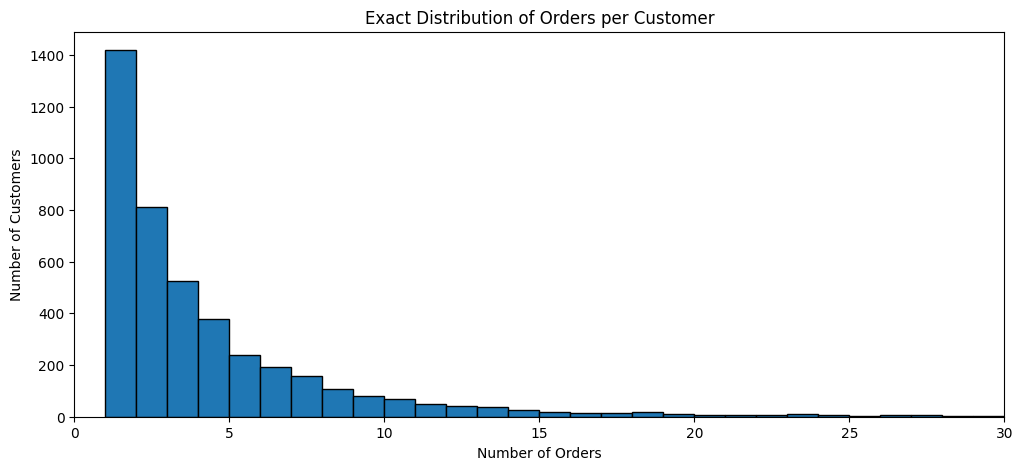

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.hist(
    customer_df["Total_Orders"],
    bins=range(1, customer_df["Total_Orders"].max() + 2),
    edgecolor="black"
)

plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Exact Distribution of Orders per Customer")

plt.xlim(0, 30)

plt.show()

# customer-behavior analysis

In [58]:
recency_by_type = (
    customer_df
    .groupby("Customer_Type")["Days_Since_Last_Purchase"]
    .agg(["mean", "median"])
    .round(2)
    .reset_index()
)

recency_by_type.columns = [
    "Customer_Type",
    "Average_Recency_Days",
    "Median_Recency_Days"
]

display(recency_by_type)

,Customer_Type,Average_Recency_Days,Median_Recency_Days
0,One-Time,150.58,126.0
1,Repeat,60.54,34.0


# Save cleaned Dataset

In [59]:
# Save cleaned transactions
df_clean.to_csv("ecommerce_cleaned_transactions.csv", index=False)

print("Saved: ecommerce_cleaned_transactions.csv")
print("Shape:", df_clean.shape)

Saved: ecommerce_cleaned_transactions.csv
Shape: (410732, 9)


In [60]:
# Save customer-level data
customer_df.to_csv("customer_analytics.csv", index=False)

print("Saved: customer_analytics.csv")
print("Shape:", customer_df.shape)

Saved: customer_analytics.csv
Shape: (4312, 19)
